# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
print(df.head())

  id_cliente  edad  nivel_ingreso  visitas_mes  compras_mes  \
0  CL-100000  44.0       28565.77            9            1   
1  CL-100001  36.0       29673.44           11            3   
2  CL-100002  46.0       30642.95            9            0   
3  CL-100003  56.0       39468.61            8            0   
4  CL-100004  35.0       22527.83            9            2   

   gasto_publicidad_dirigida  satisfaccion  miembro_premium  abandono  \
0                      31.36           3.9                0         0   
1                      24.66           3.7                0         0   
2                       0.00           2.9                0         0   
3                       6.81           3.1                0         0   
4                      26.49           2.3                0         0   

  tipo_dispositivo region  ingreso_anual  
0            móvil  norte          23.22  
1           tablet    sur          93.47  
2            móvil   este           0.00  
3         

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
print(df["edad"].describe())
print()
print(df["nivel_ingreso"].describe())
print()
print(df["visitas_mes"].describe())
print()
print(df["compras_mes"].describe())
print()
print(df["gasto_publicidad_dirigida"].describe())
print()
print(df["satisfaccion"].describe())
print()
print(df["ingreso_anual"].describe())

count    15000.000000
mean        38.262400
std         11.492378
min         18.000000
25%         30.000000
50%         38.000000
75%         46.000000
max         75.000000
Name: edad, dtype: float64

count    15000.000000
mean     30019.704782
std       9833.166305
min       8000.000000
25%      23127.097500
50%      30023.745000
75%      36768.440000
max      74790.840000
Name: nivel_ingreso, dtype: float64

count    15000.000000
mean        10.029000
std          3.158189
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         25.000000
Name: visitas_mes, dtype: float64

count    15000.000000
mean         1.206467
std          1.105284
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: compras_mes, dtype: float64

count    15000.000000
mean        20.149301
std         10.880724
min          0.000000
25%         12.310000
50%         19.730000
75%         27.292500
max    


Diagnóstico inicial de variables numéricas

- `edad`máximo — Encontramos un promedio de 38, que coincide con el segundo cuartil y un maximo de 75, por lo que no tenemos valores atípicos.
- `nivel_ingreso` - El promedio es similar a la mediana, por lo que tenemos una distribución equilibrada sin sesgo hacia algún lado.
- `visitas_mes` - Nos encontramos con una distribución equilibrada, sin valores atipicos, teniendo el minimo como 1 visita y el promedio con 10 visitas por mes.
- `compras_mes` - Tenemos una distribucion equilibrada, con el valor minimo en 0, indicando que existen usuarios sin compras, el maximo 8, esto nos indica que los valores son posibles y coherentes.
- `gasto_publicidad_dirigida` - Tenemos como valor mínimo 0, por lo que existen usuarios que no tuvieron un gasto en anuncios asignado a ellos.
- `satisfaccion` - No tenemos valores fuera de la escala asignada de 1-5, con un promedio de 3.6
- `ingreso_anual`- El valor del primer cuartil es similar al minimo, por lo que al menos 25% de los clientes no generaron ingresos para la empresa.

#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df["miembro_premium"].value_counts())
print()
print(df["abandono"].value_counts())

0    12911
1     2089
Name: miembro_premium, dtype: int64

0    12739
1     2261
Name: abandono, dtype: int64


Diagnóstico inicial de variables binarias

- `miembro_premium` — Contiene únicamente 2 valores, indicando que existen mas usuarios sin suscripción premium.
- `abandono` — Únicamente tiene 2 valores, indicando que la menor cantidad de usuarios ha abandonado la plataforma.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
print(df["tipo_dispositivo"].describe())
print()
print(df["region"].describe())

count     15000
unique        3
top       móvil
freq       9818
Name: tipo_dispositivo, dtype: object

count     15000
unique        4
top       norte
freq       4395
Name: region, dtype: object


In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df["tipo_dispositivo"].value_counts(normalize=True))
print()
print(df["region"].value_counts(normalize=True))

móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — La mayoría de los usuarios accede a la plataforma desde un dispositivo móvil. Mientras que tablet es el dispositivo menos utilizado.
- `region` - Los clientes se encuentran relativamente distribuidos entre las cuatro regiones. La región norte concentra la mayor proporción de usuarios y la region este la que menos usuarios concentra. Aunque la distribución no es perfectamente uniforme, las diferencias entre regiones no son muy marcadas.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

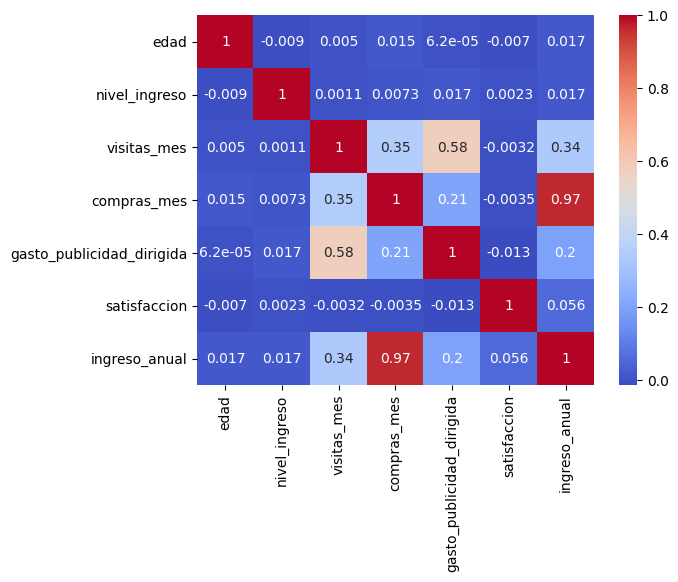

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
var_num = ["edad",
        "nivel_ingreso",
        "visitas_mes",
        "compras_mes",
        "gasto_publicidad_dirigida",
        "satisfaccion",
        "ingreso_anual"]
corr = df[var_num].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Observaciones generales (Heatmap)  
- Se observa ... En general, la mayoría de las variables presentan correlaciones bajas o cercanas a cero, lo que indica que no existe una relación lineal fuerte entre ellas. Sin embargo, se observan algunas correlaciones positivas moderadas, como entre visitas_mes y gasto_publicidad_dirigida (0.58), así como entre visitas_mes y compras_mes (0.35). La correlación más alta de la matriz corresponde a compras_mes e ingreso_anual (0.97).


Observaciones respecto a `ingreso_anual`  
- Presenta... Se observa que mantiene una correlación muy fuerte con compras_mes (0.97), lo que sugiere que el número de compras es el factor más relacionado con el ingreso generado por cada cliente. También presenta una correlación positiva moderada con visitas_mes (0.34) y una correlación débil con gasto_publicidad_dirigida (0.20). Edad, nivel_ingreso y satisfacción muestran correlaciones muy bajas, por lo que no parecen tener una relación lineal importante con el ingreso anual.

### Scatterplot general


  - No se realizará un scatterplot general, ya que el heatmap evidencia que la mayoría de las variables presentan correlaciones bajas. Además, como el objetivo del análisis es ingreso_anual, un scatterplot general aportaría poca información adicional y generaría visualizaciones poco relevantes.

### Scatterplot para pares clave

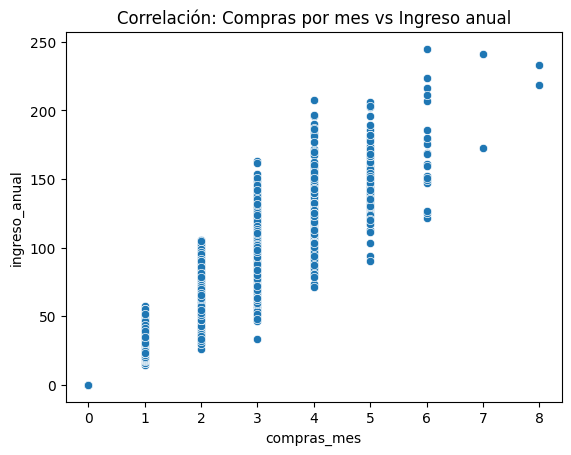

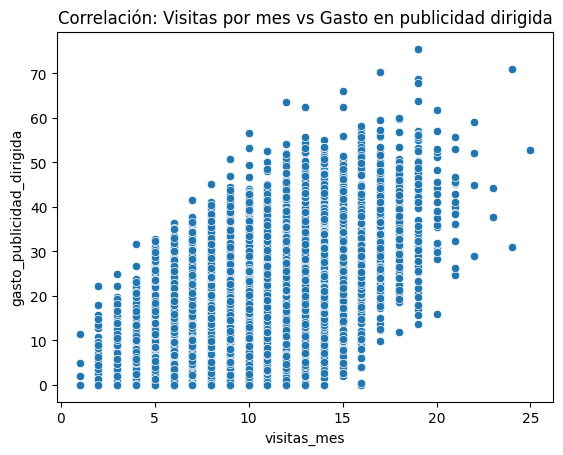

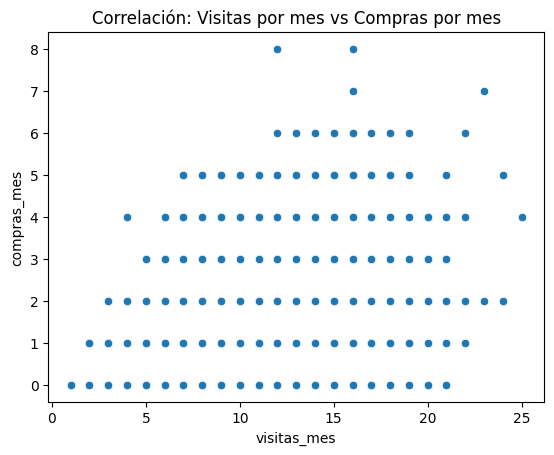

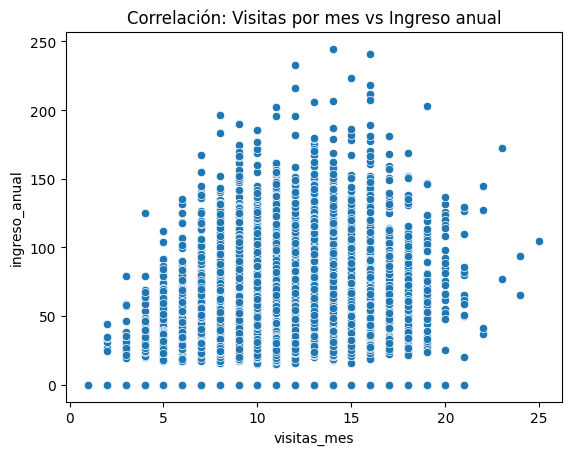

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes

# Compras vs ingreso anual
sns.scatterplot(data=df, x="compras_mes", y="ingreso_anual")
plt.title("Correlación: Compras por mes vs Ingreso anual")
plt.show()

# Visitas vs gasto en publicidad
sns.scatterplot(data=df, x="visitas_mes", y="gasto_publicidad_dirigida")
plt.title("Correlación: Visitas por mes vs Gasto en publicidad dirigida")
plt.show()

# Visitas vs compras
sns.scatterplot(data=df, x="visitas_mes", y="compras_mes")
plt.title("Correlación: Visitas por mes vs Compras por mes")
plt.show()

# Visitas vs ingreso anual
sns.scatterplot(data=df, x="visitas_mes", y="ingreso_anual")
plt.title("Correlación: Visitas por mes vs Ingreso anual")
plt.show()


Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**
- Dirección positiva, tiene dispersión baja, los puntos claramente van hacia arriba, no se observan outliers reales, los puntos más alejados mantienen la tendencia. Dado el alto valor de correlación (0.97), se puede intuir una posible colinealidad entre las variables.

**visitas_mes vs gasto_publicidad_dirigida**
- Dirección positiva, dispersión presente, existen valores con bastante variabilidad. Se observan algunos puntos con gastos en publicidad considerablemente superiores al resto, aunque no parecen alterar la tendencia general. Al tener una correlacion moderada (0.58), no indica una colinealidad importante.

**visitas_mes vs compras_mes**
- Dirección: Positiva, los puntos presentan una dispersión considerable alrededor de la tendencia. No se identifican outliers claros; los valores altos continúan el patrón observado. La correlación de 0.35 es moderada y no sugiere colinealidad.

**visitas_mes vs ingreso_anual**
- Dirección: Positiva. Aunque existe una tendencia ascendente, la variabilidad de los puntos es considerable, por lo que tenemos alta dispersión. No se observan outliers claros. La correlación de 0.34 es moderada y no representa colinealidad.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes Pearson
pares = [
    ("compras_mes", "ingreso_anual"),
    ("visitas_mes", "gasto_publicidad_dirigida"),
    ("visitas_mes", "compras_mes"),
    ("visitas_mes", "ingreso_anual")
]

for x, y in pares:
    r = df[x].corr(df[y], method="pearson")
    print(f"{x} vs {y}: {r:.3f}")

compras_mes vs ingreso_anual: 0.967
visitas_mes vs gasto_publicidad_dirigida: 0.579
visitas_mes vs compras_mes: 0.354
visitas_mes vs ingreso_anual: 0.337


In [ ]:
# Calcular correlación entre variables relevantes Spearman
pares = [
    ("compras_mes", "ingreso_anual"),
    ("visitas_mes", "gasto_publicidad_dirigida"),
    ("visitas_mes", "compras_mes"),
    ("visitas_mes", "ingreso_anual")
]

for x, y in pares:
    r = df[x].corr(df[y], method="spearman")
    print(f"{x} vs {y}: {r:.3f}")

compras_mes vs ingreso_anual: 0.967
visitas_mes vs gasto_publicidad_dirigida: 0.559
visitas_mes vs compras_mes: 0.333
visitas_mes vs ingreso_anual: 0.321



Observaciones de correlación

Los coeficientes de Pearson y Spearman presentan valores muy similares en todas las comparaciones, lo que indica que las relaciones entre las variables son aproximadamente lineales, confirmando lo observado en los diagramas de dispersión.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

coef, p_value = pointbiserialr(df["miembro_premium"],df["ingreso_anual"])
print("miembro_premium vs ingreso_anual")
print(f"Coeficiente: {coef}")
print(f"Valor p: {p_value: .5f}")

print()

print("abandono vs ingreso_anual")
coef, p_value = pointbiserialr(df["abandono"],df["ingreso_anual"])
print(f"Coeficiente: {coef}")
print(f"Valor p: {p_value: .5f}")

miembro_premium vs ingreso_anual
Coeficiente: 0.0930994396198015
Valor p:  0.00000

abandono vs ingreso_anual
Coeficiente: -0.002823934021617148
Valor p:  0.72947



Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Se tiene una dirección positiva; el valor 0.093 nos indica una correlación débil.

**abandono vs ingreso_anual**
- Se tiene una dirección negativa, con un valor de -0.00282 tenemos una correlacion débil

### V de Cramér

In [ ]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def v_cramer(col1, col2):

    # Tabla de contingencia
    tabla = pd.crosstab(col1, col2)

    # Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(tabla)

    # Total de observaciones
    n = tabla.sum().sum()

    # Número mínimo de categorías
    k = min(tabla.shape)

    # Coeficiente V de Cramér
    return np.sqrt(chi2 / (n * (k-1)))

In [ ]:
# Aplicar V de Cramér en variables relevantes

cramer= v_cramer(df["region"], df["tipo_dispositivo"])
print(f"region vs tipo_dispositivo: {cramer}")

region vs tipo_dispositivo: 0.012378338407739397



El coeficiente V de Cramér fue de 0.012, lo que indica una asociación prácticamente nula entre la región geográfica del cliente y el tipo de dispositivo utilizado para acceder a la plataforma. Esto sugiere que el dispositivo empleado es independiente de la región del usuario y no existe una relación relevante entre ambas variables.


## Sección 5 - Interpretación de resultados para el negocio

---

### Hallazgo 1 — El número de compras mensuales está fuertemente asociado con el ingreso anual.

**Evidencia visual:**   
Hetmap de correlaciones, donde encontramos valor de 0.97, ademas del scatterplot compras_mes vs ingreso_anual.

**Evidencia numérica:**
Coeficiente de pearson de 0.967, teniendo en spearman el mismo valor.

**Interpretación**  
Existe una asociación lineal muy fuerte entre el número de compras mensuales y el ingreso anual generado por el cliente. Los clientes que realizan más compras tienden a generar mayores ingresos.

**No podemos afirmar**  
No se puede concluir que incrementar el número de compras cause directamente un mayor ingreso anual, ya que el análisis es correlacional y no establece relaciones de causa-efecto.

**Implicación de negocio**  
Conviene diseñar estrategias para incentivar la frecuencia de compra, como programas de fidelización, promociones o recomendaciones personalizadas, ya que los clientes con mayor actividad de compra están asociados con mayores ingresos.

### Hallazgo 2 — Ser miembro premium presenta una asociación muy débil con el ingreso anual.

**Evidencia visual:**   
No aplica.

**Evidencia numérica:**
Coeficiente de punto biserial de 0.093

**Interpretación**  
Existe una asociación positiva, pero muy débil, entre ser miembro premium y el ingreso anual. Aunque la relación es estadísticamente significativa, su magnitud es pequeña.


**No podemos afirmar**  
No se puede concluir que convertirse en miembro premium incremente el ingreso anual del cliente.

**Implicación de negocio**  
El programa premium, por sí solo, no parece estar fuertemente relacionado con un mayor ingreso anual. Sería recomendable evaluar si los beneficios ofrecidos son suficientes o si existen otros factores que influyen más en el comportamiento de compra de los clientes.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- El análisis es de carácter correlacional, por lo que las asociaciones identificadas no permiten establecer relaciones de causalidad entre las variables. Por lo que: correlación ≠ causalidad.
- El análisis se centró principalmente en relaciones lineales entre variables numéricas y asociaciones entre variables binarias o categóricas mediante los coeficientes de Pearson, punto biserial y V de Cramér. Debido a ello, no fue posible evaluar directamente la relación entre ingreso_anual y variables categóricas con más de dos categorías, como región y tipo_dispositivo, ya que estos coeficientes no son adecuados para ese tipo de comparación.

### **Próximos pasos**

Probar segmentación adicional
- Segmentar por región o tipo de dispositivo, comparando métricas como compras, satisfacción e ingreso anual
- Segmentar por frecuencia de compra o visitas.

Analizar causas de abandono
- Profundizar en el análisis de variables relacionadas con el comportamiento del cliente, por ejemplo, estudiar los factores asociados al abandono y determinar qué características influyen en la pérdida de clientes.

Revisar region y tipo de dispositivo
- Analizar por region y tipo de dispositivo para entender la relacion que tienen estas variables con el ingreso anual del cliente